In [1]:
import os,sys,subprocess,glob,importlib,pickle,itertools,string
from datetime import datetime
import xarray as xr
import numpy as np
import pandas as pd
import scipy,math


from sup.sup_plotting import *
from sup.useful_functions import *

from pickles.load_pickle_1D import *

from sup.merged_ensembles import *

%load_ext autoreload
%autoreload 2

In [2]:
ensembles = prep_data()

In [3]:
def get_sim_step_names(ens):
    sims = ens['data']['weight'].sim.values

    if ens['exp'].ensemble_type == 'rea':
        sims = np.array([s.split('.')[1:] for s in sims])
    elif ens['exp'].ensemble_type == 'rea_legacy':
        sims = np.array([s.split('/') for s in sims])
    else:
        asdasd

    return sims


In [4]:
def get_uniqueness(ens):
    uniqueness = xr.DataArray(dims=['sim','step'], coords=dict(sim=ens['data']['weight'].sim.values,step=np.arange(0,ens['exp'].n_steps,1,'int')))
    sims = get_sim_step_names(ens)

    for step in uniqueness.step.values:
        for v in np.unique(sims[:,step]):
            same = (sims[:,step] == v)
            uniqueness[same, step] = 1 / same.sum()
    return uniqueness

In [5]:
for ens_name, ens in ensembles.items():
    if 'initial' not in ens_name:
        ens['data']['uniqueness'] = get_uniqueness(ens)

In [6]:
for ens_name, ens in ensembles.items():
    if 'initial' not in ens_name:
        if int(ens_name.split('-x')[-1]) < 6:
            surviving = np.unique(get_sim_step_names(ens)[:,0]).shape[0]
            print(ens_name,  surviving, int(np.round(surviving/ens['exp'].n_members * 100)))


ssp370-2025-x1 16 13
ssp370-2025-x2 32 25
ssp370-2025-x3 29 23
ssp370-2025-x4 36 29
ssp370-2025-x5 21 17
piControl-x1 25 20
piControl-x2 31 25
piControl-x3 35 28
piControl-x4 29 23
piControl-x5 23 18


In [7]:
np.mean([25,23,29,25,28,23])

25.5

In [8]:
np.mean([13,17,20,18])

17.0

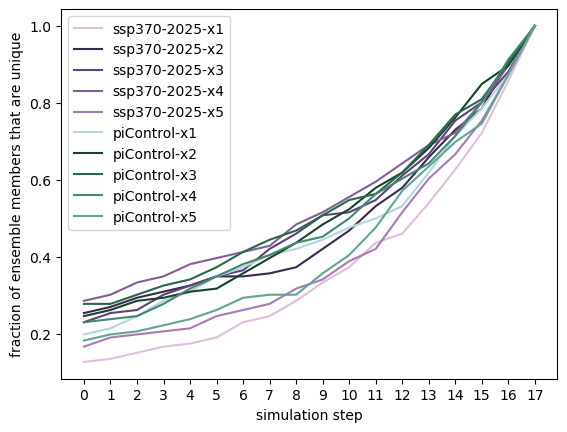

In [12]:
fig,ax = plt.subplots()
for ens_name, ens in ensembles.items():
    if 'initial' not in ens_name:
        if int(ens_name.split('-x')[-1]) < 6:
            uniqueness = ens['data']['uniqueness']
            ax.plot(uniqueness.sum('sim') / 126, color=ens['color'], label=ens_name)
ax.set_ylabel('fraction of ensemble members that are unique')
ax.set_xlabel('simulation step')
ax.set_xticks(range(0,18))
ax.legend()
savefig('meta/uniqueness')

In [ ]:
fig,ax = plt.subplots()
for i,ens in enumerate(gklt_ensembles.values()):
    initials = np.unique([s.split('/')[0] for s in ens._diff.sim.values])
    uniqueness = []
    for ini,color in zip(initials, distinctipy.get_colors(len(initials))):
        l = []
        for sim in ens._diff.sim.values:
            if sim.split('/')[0] == ini:
                l.append(sim)

        uniqueness.append(18)
        for i in range(1,len(l)):
            c = np.array([np.sum(np.array(l[i].split('/')) == np.array(l[j].split('/'))) for j in range(i)])
            uniqueness.append(np.min(18 - c))
    #ax.plot(sorted(uniqueness), color=ens._color, label=ens._label)
    ax.plot(sorted(uniqueness), color=ens._color, label=ens._label)
ax.set_ylabel('uniqueness')
ax.set_yticks(range(1,19))
ax.legend()

/tmp/ipykernel_3821302/1343968418.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 400x300 with 2 Axes> than <Figure size 50x300 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(im, cax=ax, orientation='vertical', label='uniqueness')


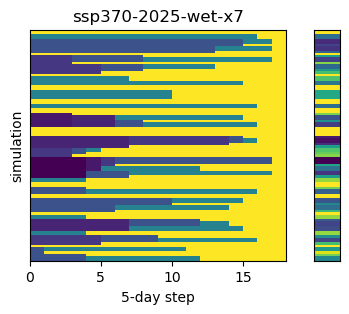

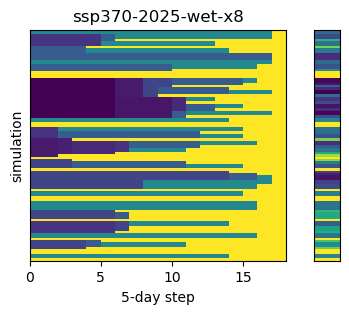

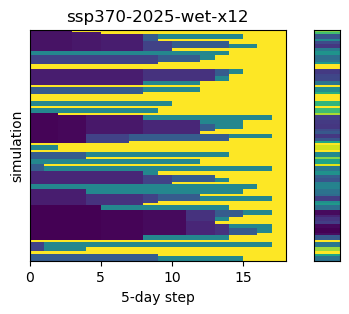

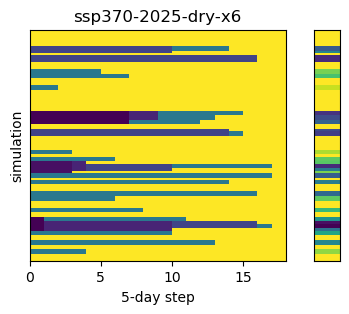

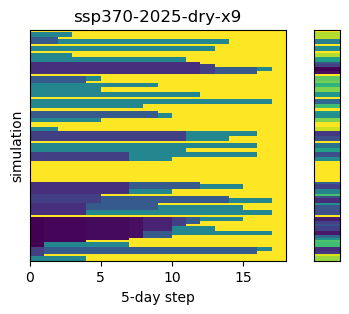

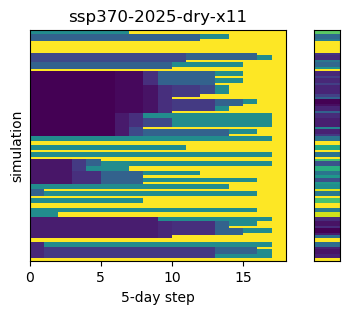

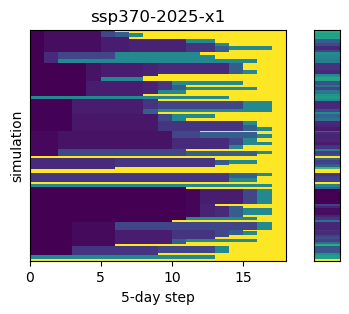

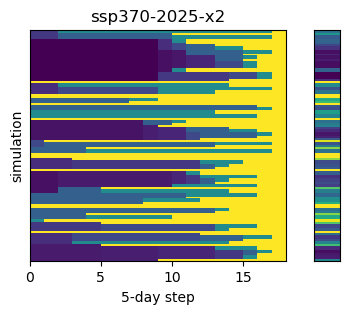

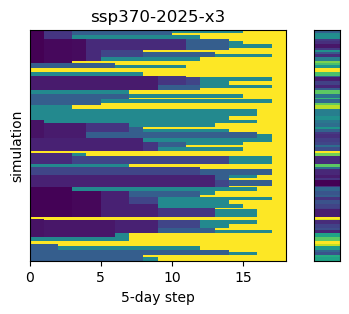

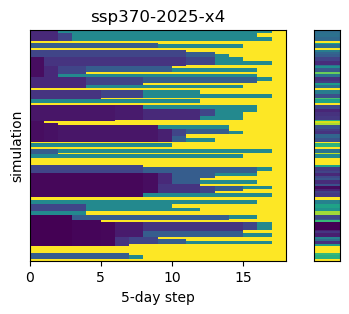

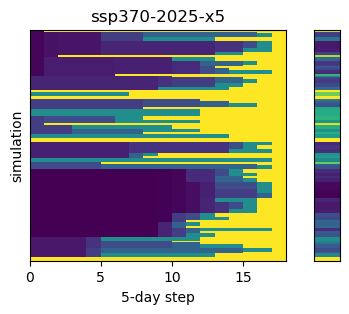

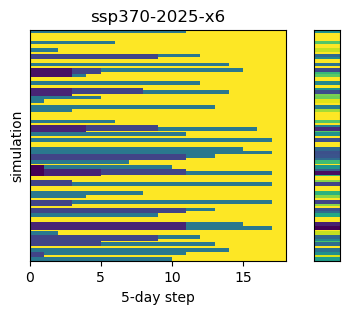

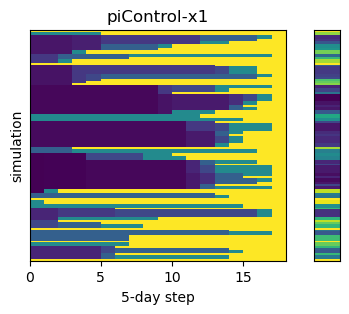

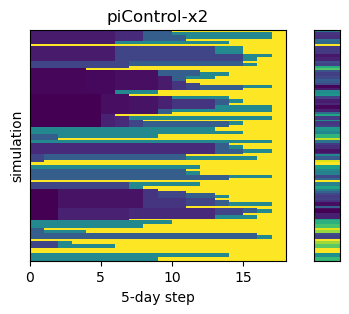

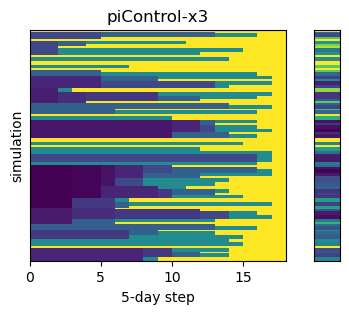

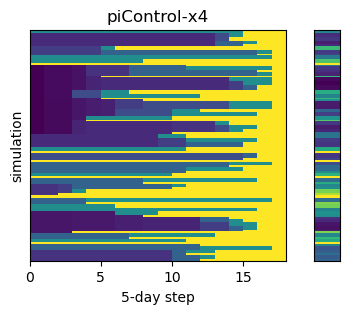

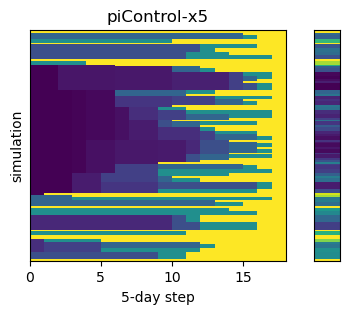

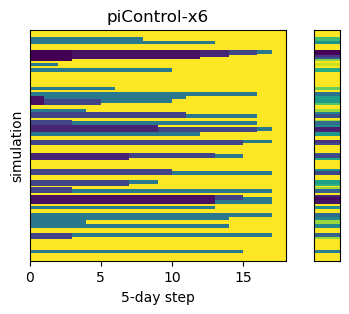

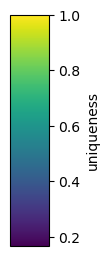

In [65]:
for ens_name, ens in ensembles.items():
    if 'initial' not in ens_name:
        fig,axes = plt.subplots(ncols=2, figsize=(4,3), gridspec_kw=dict(width_ratios=[10,1]), sharey=True)
        axes[0].set_title(ens_name)
        im = axes[0].pcolormesh(ens['data']['uniqueness'])
        axes[1].pcolormesh(np.array([ens['data']['uniqueness'].mean('step').values]).T)
        axes[0].set_ylabel('simulation')
        axes[0].set_xlabel('5-day step')
        axes[1].set_yticks([])
        axes[1].set_xticks([])
        savefig(f'meta/uniqueness_{ens_name}', transparent=True)

fig,ax = plt.subplots(figsize=(0.5,3))
plt.colorbar(im, cax=ax, orientation='vertical', label='uniqueness')
savefig(f'meta/uniqueness_cbar', transparent=True)